In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/CleanedSalesData.csv')
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Total_Amount,Total_Sales,Avg_Item_Price,Discount_Percentage,Profit,Profit_Margin,Engagement_Score,Pages_Per_Minute,Is_Delayed,Rating_Category
0,ORD_000001-1,CUST_00001,2023-05-28,40,Male,Delhi (NCR),Books,29.18,1,0.00,...,29.18,29.18,29.18,0.000000,8.754,30.000000,126,0.642857,True,Excellent
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Delhi (NCR),Home & Garden,644.40,1,138.05,...,506.35,506.35,506.35,21.423029,55.270,10.915375,112,0.571429,False,Poor
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Delhi (NCR),Sports,332.82,5,0.00,...,1664.10,1664.10,332.82,0.000000,499.230,30.000000,150,0.666667,True,Excellent
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Bengaluru,Food,69.30,5,71.05,...,275.45,275.45,55.09,20.505051,32.900,11.944091,208,0.812500,False,Excellent
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Bengaluru,Beauty,178.15,3,0.00,...,534.45,534.45,178.15,0.000000,160.335,30.000000,98,0.500000,False,Excellent


In [3]:
category_sales = (
    df.groupby("Product_Category")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Product_Category,Total_Sales
0,Electronics,10481897.65
1,Home & Garden,4023903.94
2,Sports,3205086.99
3,Fashion,1577035.70
4,Toys,1014237.53
5,Beauty,694437.02
6,Food,422054.65
7,Books,360399.11


In [4]:
category_profit = (
    df.groupby("Product_Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_profit

,Product_Category,Profit
0,Electronics,2746845.710
1,Home & Garden,1048558.448
2,Sports,837411.624
3,Fashion,415103.607
4,Toys,266825.207
5,Beauty,180826.951
6,Food,109817.046
7,Books,95454.640


In [5]:
city_sales = (
    df.groupby("City")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

city_sales

,City,Total_Sales
0,Bengaluru,5646595.78
1,Delhi (NCR),3052443.10
2,Mumbai,2651743.92
3,Hyderabad,2317028.10
4,Chennai,1661594.15
5,Kolkata,1573422.25
6,Pune,1512320.19
7,Ahmedabad,1363152.80
8,Lucknow,1091658.53
9,Jaipur,909093.77


In [6]:
gender_sales = (
    df.groupby("Gender")["Total_Sales"]
      .sum()
      .reset_index()
)

gender_sales

,Gender,Total_Sales
0,Female,11037984.60
1,Male,10343185.70
2,Other,397882.29


In [8]:
df['Is_Returning_Customer'].value_counts()

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64

In [7]:
return_sales = (
    df.groupby("Is_Returning_Customer")["Total_Sales"]
      .mean()
      .reset_index()
)

return_sales

,Is_Returning_Customer,Total_Sales
0,False,1287.727428
1,True,1276.063599


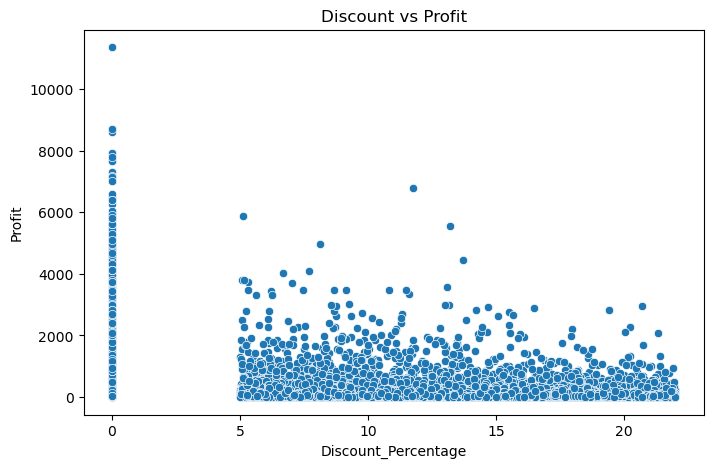

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount_Percentage",
    y="Profit"
)

plt.title("Discount vs Profit")

plt.show()

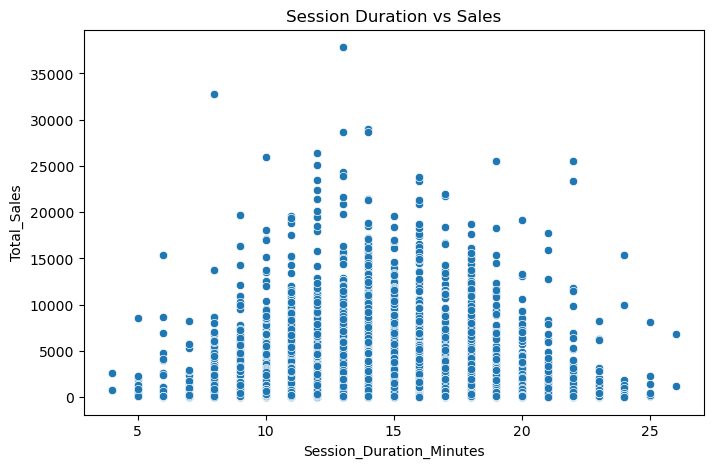

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Session_Duration_Minutes",
    y="Total_Sales"
)

plt.title("Session Duration vs Sales")

plt.show()

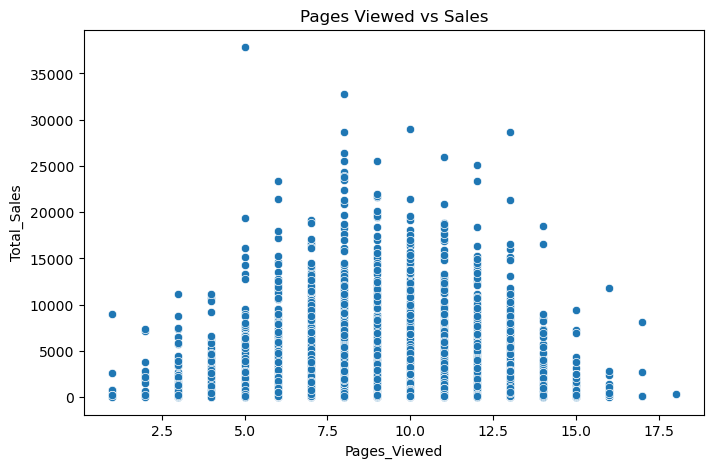

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Pages_Viewed",
    y="Total_Sales"
)

plt.title("Pages Viewed vs Sales")

plt.show()

# Bivariate Analysis

Bivariate analysis was performed to understand the relationships between important business variables and identify factors influencing sales, profitability, customer engagement, and regional performance.

## Discount Percentage vs Profit

The relationship between discount percentage and profit indicates that profitability is influenced by multiple factors rather than discounts alone.

- Orders without discounts include some of the highest-profit transactions.
- Moderate discounts continue to generate substantial profits.
- Higher discounts do not consistently lead to higher or lower profits.
- No strong linear relationship is observed between discount percentage and profitability.

This suggests that pricing strategy, product value, and order size play a more significant role in determining profit than discounts alone.

---

## Session Duration vs Total Sales

Customer browsing time shows a moderate positive relationship with total sales.

- Most high-value purchases occur during sessions lasting approximately 10 to 18 minutes.
- Very short browsing sessions generally correspond to lower transaction values.
- Extremely long sessions do not necessarily result in higher sales.

These observations indicate that meaningful customer engagement positively influences purchasing behavior.

---

## Pages Viewed vs Total Sales

The relationship between pages viewed and total sales suggests that customers often explore multiple products before making a purchase.

- Customers viewing approximately 7 to 12 pages account for the majority of high-value transactions.
- Lower page views generally correspond to lower sales.
- Beyond a certain browsing level, additional page views do not significantly increase purchase value.

This indicates that product discovery supports purchasing decisions, although excessive browsing does not guarantee higher spending.

---

## Product Category Performance

Sales and profit analysis across product categories reveals clear differences in business performance.

- Electronics generates the highest total sales and profit.
- Home & Garden and Sports are the next strongest performing categories.
- Fashion and Toys contribute moderate revenue.
- Beauty, Food, and Books generate comparatively lower sales and profits.

Overall, the company's revenue is concentrated in a few high-performing product categories.

---

## City-wise Sales Performance

Sales distribution across cities highlights regional differences in customer demand.

- Bengaluru is the highest revenue-generating city.
- Delhi (NCR), Mumbai, and Hyderabad also contribute significantly to overall sales.
- Jaipur and Lucknow generate the lowest sales among the selected cities.

These findings suggest stronger market penetration in metropolitan regions compared to smaller cities.

---

# Summary

The bivariate analysis highlights several important business insights:

- Discounts alone do not determine profitability.
- Moderate customer engagement is associated with higher sales.
- Customers typically browse multiple products before making purchasing decisions.
- Electronics is the company's strongest-performing product category in both revenue and profit.
- Major metropolitan cities contribute the largest share of total sales.

These insights provide valuable guidance for pricing strategies, customer engagement initiatives, product management, and regional business expansion.